In [2]:
import pandas as pd

data=pd.read_csv("superstore_data.csv",encoding='latin-1') # Assuming 'superstore_data.csv' is uploaded to Colab's default directory
print(data.head())
print(data.shape)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [3]:
#Checking missing values
data.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [4]:
#we have 11 null values in Postal Code column so we are making the null values into zero
data["Postal Code"]=data["Postal Code"].fillna(0).astype(int)

In [5]:
data.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
data['Order Date']=pd.to_datetime(data['Order Date'])
data['Ship Date']=pd.to_datetime(data['Ship Date'])

In [7]:
data['Order Year']=data['Order Date'].dt.year
data['Order Month']=data['Order Date'].dt.month
data['Ship Days']=(data['Ship Date']-data['Order Date']).dt.days
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Ship Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1,2
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2,5
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2,5
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2,5


In [8]:
#Check for duplicates
print("Duplicates: ",data.duplicated().sum())

Duplicates:  0


In [9]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Ship Days'],
      dtype='object')

In [10]:
#Making column corrected and in same way manner
#Select the columns that has String data type
columns=data[['Category','Country','Ship Mode','Customer Name','Segment','City','State','Region','Sub-Category','Product Name']]
for col in columns:
  data[col]=data[col].str.strip().str.title()

# str.strip() will do the following
# if we have " furniture" element under Category column
# it has extra space before 'f', this makes it as an different from "furniture"
# so it trims the extra spaces before and after the string elements

#str.title()
#It makes the first letter of the word into caps and the rest in to small
#It gives an uniform texture for all the elements in a column

In [11]:
#Understand the numeric column data
print(data[['Sales','Quantity','Profit','Discount']].describe())

              Sales     Quantity       Profit     Discount
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574    28.656896     0.156203
std      623.245101     2.225110   234.260108     0.206452
min        0.444000     1.000000 -6599.978000     0.000000
25%       17.280000     2.000000     1.728750     0.000000
50%       54.490000     3.000000     8.666500     0.200000
75%      209.940000     5.000000    29.364000     0.200000
max    22638.480000    14.000000  8399.976000     0.800000


In [12]:
print(data.dtypes)
print(data.isnull().sum())
print(data.shape)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Order Year                int32
Order Month               int32
Ship Days                 int64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Co

##  EDA

  <ol><li>Sales Trends<br>
  <li>Time trends<br>
  <li>Discounting and Profitablity<br>
  <li>Customer segments<br>
  <li>Shipping and Operations</li></ol>


# Sales Trends






In [13]:
#EDA
data.groupby('Category')[['Sales','Profit']].sum().sort_values(by='Profit',ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728


In [14]:
data.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values(by='Profit')

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


In [15]:
data.groupby('Region')[['Sales','Profit']].sum()

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


# Time Trends

In [16]:
data.groupby('Order Year')[['Sales','Profit']].sum()

,Sales,Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [17]:
data.groupby('Order Month')[['Sales','Profit']].sum().sort_index()

,Sales,Profit
Order Month,,
1,94924.8356,9134.4461
2,59751.2514,10294.6107
3,205005.4888,28594.6872
4,137762.1286,11587.4363
5,155028.8117,22411.3078
6,152718.6793,21285.7954
7,147238.0970,13832.6648
8,159044.0630,21776.9384
9,307649.9457,36857.4753


In [18]:
data.groupby(['Order Month','Order Year'])[['Sales']].sum().unstack()

Sales                                     
Order Year         2014        2015        2016         2017
Order Month                                                 
1            14236.8950  18174.0756  18542.4910   43971.3740
2             4519.8920  11951.4110  22978.8150   20301.1334
3            55691.0090  38726.2520  51715.8750   58872.3528
4            28295.3450  34195.2085  38750.0390   36521.5361
5            23648.2870  30131.6865  56987.7280   44261.1102
6            34595.1276  24797.2920  40344.5340   52981.7257
7            33946.3930  28765.3250  39261.9630   45264.4160
8            27909.4685  36898.3322  31115.3743   63120.8880
9            81777.3508  64595.9180  73410.0249   87866.6520
10           31453.3930  31404.9235  59687.7450   77776.9232
11           78628.7167  75972.5635  79411.9658  118447.8250
12           69545.6205  74919.5212  96999.0430   83829.3188

# Discounting and Profitablity



<Axes: xlabel='Discount', ylabel='Profit'>

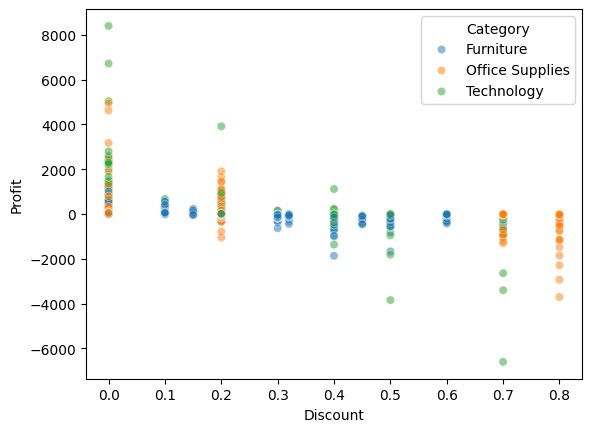

In [19]:
import seaborn as sns
sns.scatterplot(data=data,x='Discount',y='Profit',hue='Category',alpha=0.5)


In [20]:
data.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)

,Discount
Sub-Category,
Binders,0.372292
Machines,0.306087
Tables,0.261285
Bookcases,0.211140
Chairs,0.170178
Appliances,0.166524
Copiers,0.161765
Phones,0.154556
Furnishings,0.138349


  <head style="align:center">Customer Segments</head>

In [21]:
data.groupby('Segment')[['Sales','Profit']].sum()

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [22]:
data.groupby(['Segment','Region'])['Sales'].sum().unstack()

Region,Central,East,South,West
Segment,,,,
Consumer,252031.4340,350908.167,195580.9710,362880.7730
Corporate,157995.8128,200409.347,121885.9325,225855.2745
Home Office,91212.6440,127463.726,74255.0015,136721.7770


In [23]:
data.groupby('Ship Mode')[['Sales']].agg(['mean','count'])

Sales      
                      mean count
Ship Mode                       
First Class     228.497024  1538
Same Day        236.396179   543
Second Class    236.089239  1945
Standard Class  227.583067  5968

# Visualization

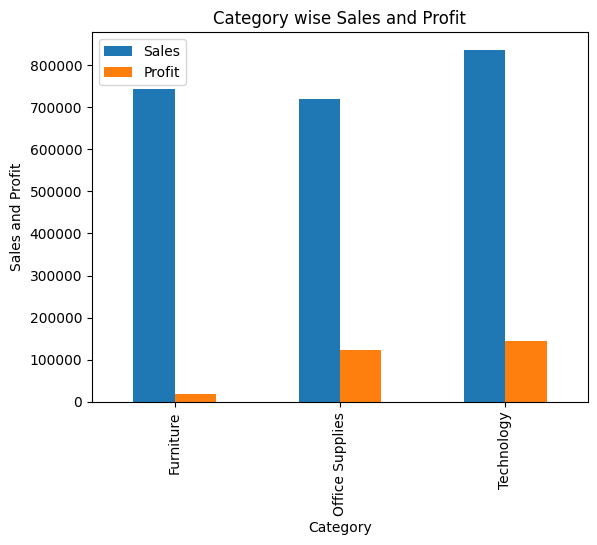

In [24]:
import matplotlib.pyplot as plt
cat_df=data.groupby('Category')[['Sales','Profit']].sum()

cat_df.plot(kind='bar')
plt.title('Category wise Sales and Profit')
plt.ylabel('Sales and Profit')
plt.show()

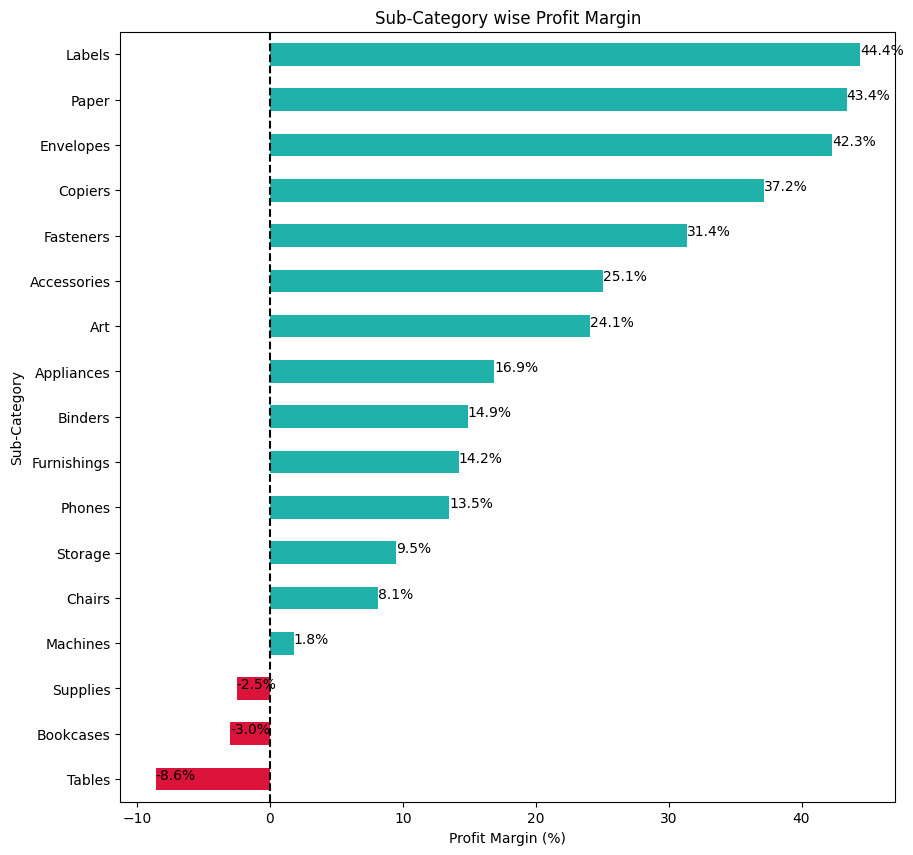

In [25]:
sub_df=data.groupby('Sub-Category')[['Sales','Profit']].sum()
sub_df['Margin%']=(sub_df['Profit']/sub_df['Sales']*100).round(1)
sub_df=sub_df.sort_values('Margin%')

# Changed 'crimson red' to a valid hex code for crimson (#DC143C)
colors=['#DC143C' if m<0 else 'lightseagreen' for m in sub_df['Margin%']]

sub_df['Margin%'].plot(kind='barh',color=colors,figsize=(10,10))
plt.title('Sub-Category wise Profit Margin')
plt.xlabel('Profit Margin (%)')
plt.axvline(0,color='black',linestyle='--')
for i in range(len(sub_df)):
    val = sub_df['Margin%'].iloc[i]
    plt.text(val, i, str(val) + '%')
plt.show()

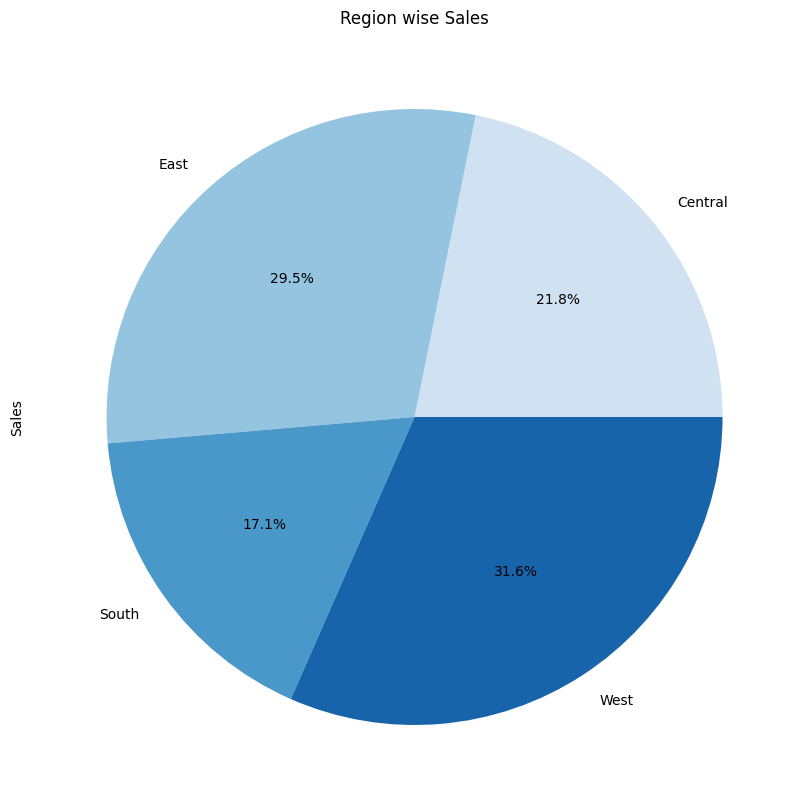

In [26]:
import numpy as np
region_sales=data.groupby('Region')['Sales'].sum()
colors=plt.cm.Blues(np.linspace(0.2,0.8,len(region_sales)))
region_sales.plot(kind='pie',autopct='%1.1f%%',figsize=(10,10),colors=colors)
plt.title('Region wise Sales')
plt.show()

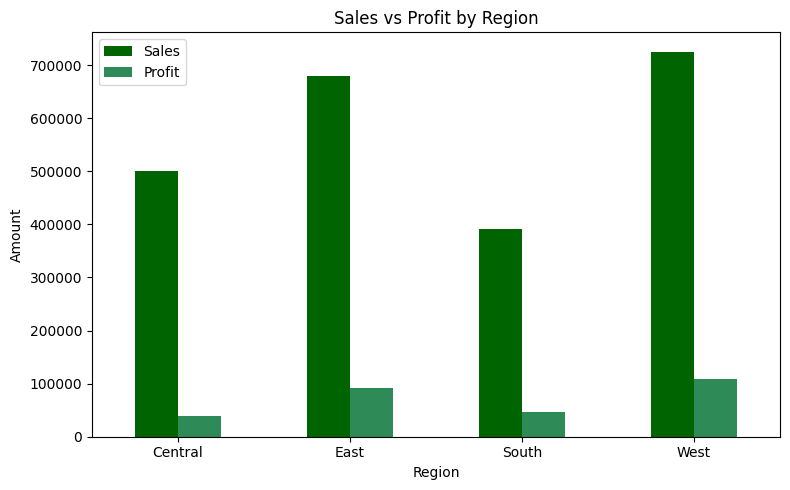

In [27]:
import matplotlib.pyplot as plt

# Step 1: group data
reg_df = data.groupby('Region')[['Sales', 'Profit']].sum()

# Step 2: plot grouped bar chart
reg_df.plot(kind='bar', figsize=(8,5), color=['darkgreen', 'seagreen'])

# Step 3: labels
plt.title('Sales vs Profit by Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend()

# Step 4: show
plt.tight_layout()
plt.show()

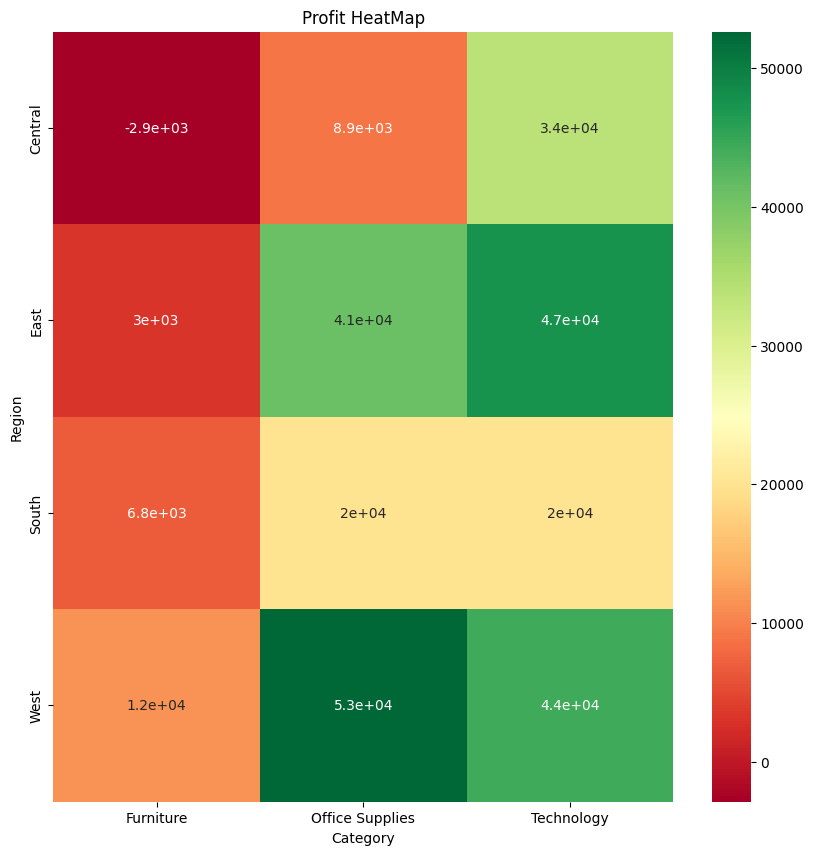

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

pivott=data.pivot_table(values='Profit',index='Region',columns='Category',aggfunc='sum')

plt.figure(figsize=(10,10)) # Create a figure with the desired size
sns.heatmap(pivott,annot=True,cmap='RdYlGn')
plt.title('Profit HeatMap')
plt.show()

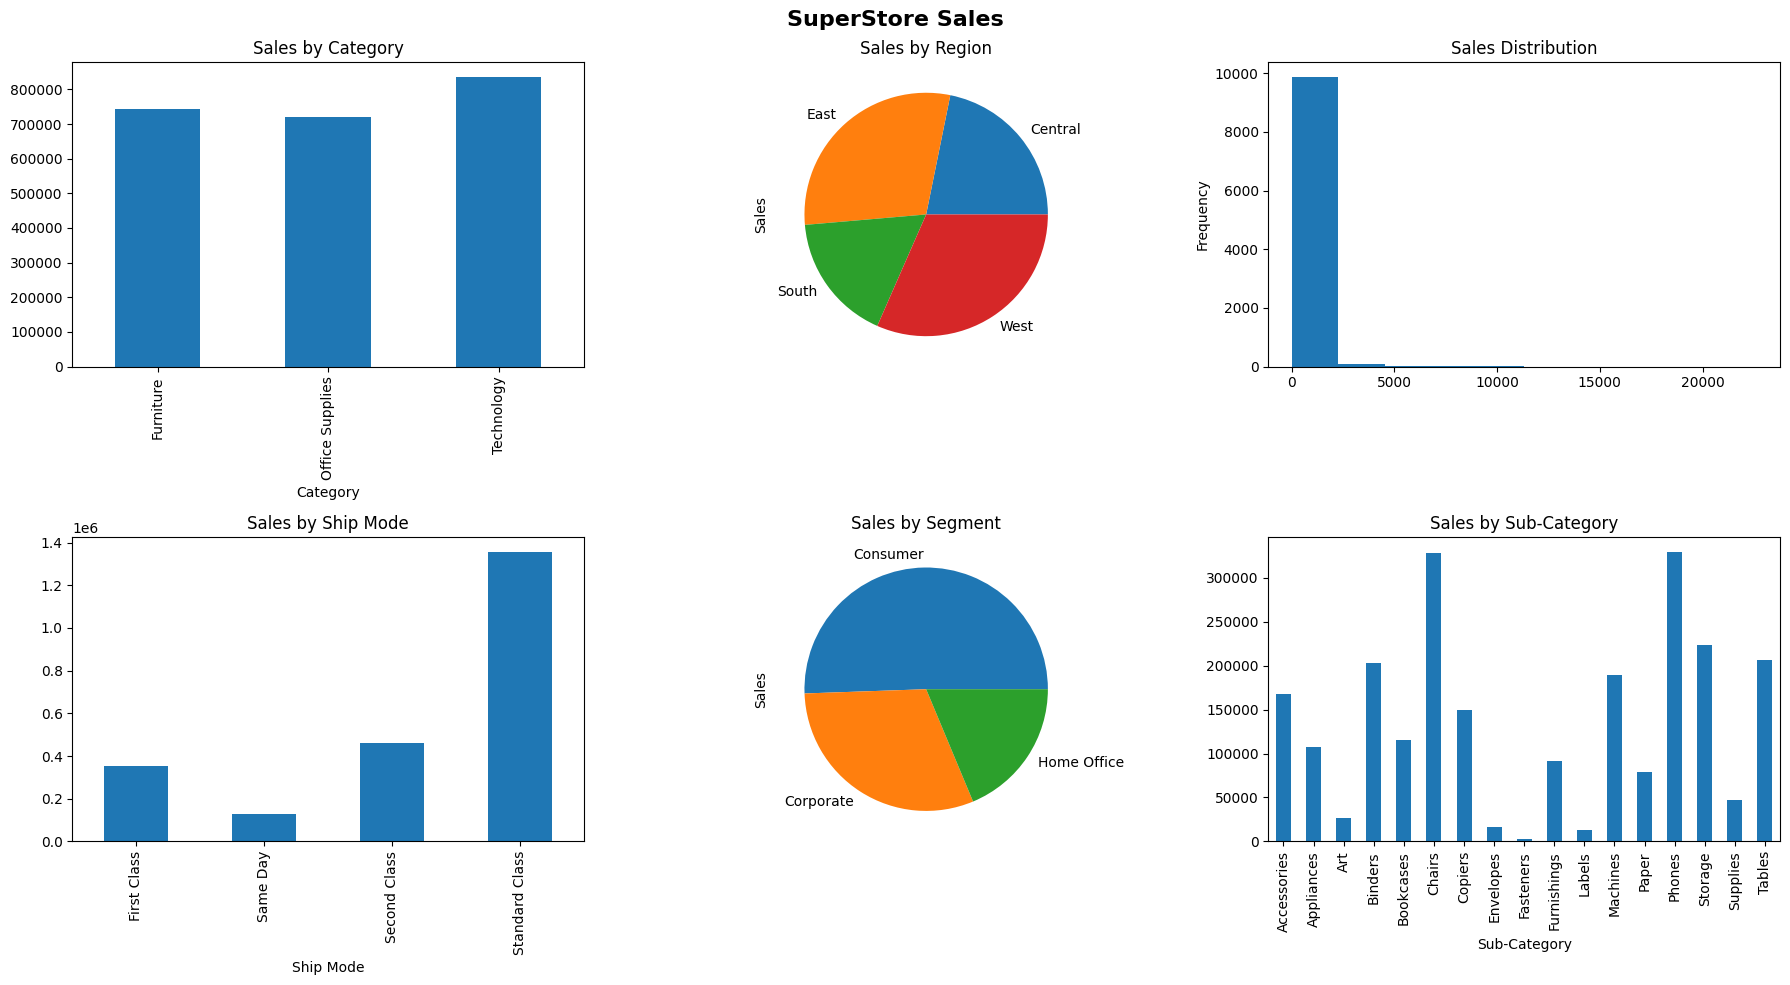

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plt.suptitle('SuperStore Sales',fontsize=16,fontweight='bold')
# Chart 1
data.groupby('Category')['Sales'].sum().plot(kind='bar', ax=axes[0][0])
axes[0][0].set_title('Sales by Category')

# Chart 2
data.groupby('Region')['Sales'].sum().plot(kind='pie', ax=axes[0][1])
axes[0][1].set_title('Sales by Region')

# Chart 3
data['Sales'].plot(kind='hist', ax=axes[0][2])
axes[0][2].set_title('Sales Distribution')

#Chart4
data.groupby('Ship Mode')['Sales'].sum().plot(kind='bar', ax=axes[1][0])
axes[1][0].set_title('Sales by Ship Mode')

#chart5
data.groupby('Segment')['Sales'].sum().plot(kind='pie', ax=axes[1][1])
axes[1][1].set_title('Sales by Segment')

#chart6
data.groupby('Sub-Category')['Sales'].sum().plot(kind='bar', ax=axes[1][2])
axes[1][2].set_title('Sales by Sub-Category')

plt.tight_layout()
plt.show()